# MATH GR5360 Final Project - Notebook 2
## Channel WithDDControl Strategy & Walk-Forward Optimization

**Columbia University - Mathematical Methods in Financial Price Analysis**

---

## ⚠️ CONFIGURE YOUR GROUP'S MARKET BELOW ⚠️

In [2]:

PRIMARY_MARKET = 1  



In [3]:
MARKET_DATABASE = {
    'BO': ('Soybean Oil', 'CBOT-CME', 600, 39, 6, 1),
    'DX': ('Dollar Index', 'NYBOT-ICE', 1000, 16.5, 5, 1),
    'HG': ('Copper', 'COMEX-NYMEX-CME', 250, 59.25, 12.5, 1),
    'HO': ('Heating Oil', 'NYMEX-CME', 420, 70.2, 4.2, 100),
    'JO': ('Orange Juice', 'NYBOT-ICE', 150, 183, 7.5, 1),
    'JY': ('Japanese Yen', 'CME', 1250, 53, 6.25, 100),
    'SY': ('Soybeans', 'CBOT-CME', 50, 35.5, 12.5, 1),
    'SB': ('Sugar #11', 'NYBOT-ICE', 1120, 56.76, 11.2, 1),
    'SF': ('Swiss Franc', 'CME', 1250, 25.5, 12.5, 100),
    'TU': ('2-Year Treasury', 'CBOT-CME', 2000, 18.625, 15.625, 1),
    'TY': ('10-Year Treasury', 'CBOT-CME', 1000, 18.625, 15.625, 1),
    'WC': ('Wheat', 'CBOT-CME', 50, 30.5, 12.5, 1),
    'SM': ('Soybean Meal', 'CBOT-CME', 100, 57, 10, 1),
    'CC': ('Cocoa', 'NYBOT-ICE', 10, 103, 10, 1),
    'BZ': ('Schatz', 'EUREX', 1000, 10.5, 5, 1),
    'CL': ('Crude Oil WTI', 'NYMEX-CME', 1000, 46, 10, 1),
    'GC': ('Gold 100oz', 'COMEX-NYMEX-CME', 100, 65, 10, 1),
    'SV': ('Silver', 'COMEX-NYMEX-CME', 5000, 243, 25, 0.01),
}

GROUP_TO_TICKER = {
    1: 'BO', 2: 'DX', 3: 'HG', 4: 'HO', 5: 'JO', 6: 'JY',
    7: 'SY', 8: 'SB', 9: 'SF', 10: 'TU', 11: 'TY', 12: 'WC',
    13: 'SM', 14: 'CC', 15: 'BZ', 16: 'CL', 17: 'GC', 18: 'SV'
}

TICKER = GROUP_TO_TICKER[PRIMARY_MARKET]
market_info = MARKET_DATABASE[TICKER]

MARKET = {
    'ticker': TICKER,
    'name': market_info[0],
    'exchange': market_info[1],
    'PV': market_info[2],
    'slpg': market_info[3],
    'tick_value': market_info[4],
    'pv_multiplier': market_info[5],
    'E0': 100000,
}

DATA_FILE = f'../data/{TICKER}-5minHLV.csv'

print("=" * 60)
print(f"GROUP {PRIMARY_MARKET}: {MARKET['ticker']} - {MARKET['name']}")
print(f"PV=${MARKET['PV']}, Slippage=${MARKET['slpg']}, E0=${MARKET['E0']:,}")
print("=" * 60)

GROUP 1: BO - Soybean Oil
PV=$600, Slippage=$39, E0=$100,000


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import jit
from tqdm.notebook import tqdm
from datetime import datetime
from typing import Tuple, Dict, Any
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print(f"Notebook started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

Notebook started: 2026-04-15 20:53:24


---
## 1. Load Data

In [5]:
def load_data(filepath):
    df = pd.read_csv(filepath)
    df.columns = df.columns.str.strip().str.lower()
    if 'date' in df.columns and 'time' in df.columns:
        df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str), format='mixed')
    else:
        df['datetime'] = pd.to_datetime(df.iloc[:, 0])
    df.set_index('datetime', inplace=True)
    df.sort_index(inplace=True)
    rename = {}
    for c in df.columns:
        if 'open' in c.lower(): rename[c] = 'Open'
        elif 'high' in c.lower(): rename[c] = 'High'
        elif 'low' in c.lower(): rename[c] = 'Low'
        elif 'close' in c.lower(): rename[c] = 'Close'
    df.rename(columns=rename, inplace=True)
    return df[['Open', 'High', 'Low', 'Close']].astype(float)

try:
    df = load_data(DATA_FILE)
    print(f"✓ Loaded {len(df):,} bars from {DATA_FILE}")
except FileNotFoundError:
    print(f"Generating synthetic data for {TICKER}...")
    np.random.seed(42 + PRIMARY_MARKET)
    n = 250000
    dates = pd.date_range('2008-01-01', periods=n, freq='5min')
    start_prices = {'BO': 30, 'DX': 90, 'HG': 3, 'HO': 2, 'JO': 100, 'JY': 0.009,
                    'SY': 900, 'SB': 15, 'SF': 1, 'TU': 105, 'TY': 115, 'WC': 500,
                    'SM': 300, 'CC': 2500, 'BZ': 110, 'CL': 60, 'GC': 1300, 'SV': 15}
    start_price = start_prices.get(TICKER, 100)
    returns = np.random.randn(n) * 0.0003 + np.sin(np.linspace(0, 8*np.pi, n)) * 0.0001
    close = start_price * np.exp(np.cumsum(returns))
    df = pd.DataFrame({
        'Open': close * (1 + np.random.randn(n) * 0.0001),
        'High': close * (1 + np.abs(np.random.randn(n) * 0.0003)),
        'Low': close * (1 - np.abs(np.random.randn(n) * 0.0003)),
        'Close': close
    }, index=dates)
    df['High'] = df[['Open', 'High', 'Close']].max(axis=1)
    df['Low'] = df[['Open', 'Low', 'Close']].min(axis=1)
    print(f"✓ Generated {len(df):,} synthetic bars")

Generating synthetic data for BO...
✓ Generated 250,000 synthetic bars


---
## 2. Channel WithDDControl Strategy (Exact Port of main.m)

In [6]:
@jit(nopython=True, cache=True)
def channel_strategy(
    Open: np.ndarray, High: np.ndarray, Low: np.ndarray, Close: np.ndarray,
    L: int, S: float, slpg: float, PV: float, E0: float, barsBack: int
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Channel WithDDControl - Exact port of main.m MATLAB code.
    
    Parameters:
    -----------
    L : int - Channel length (ChnLen)
    S : float - Stop percentage (StpPct)
    slpg : float - Slippage (round-turn, USD)
    PV : float - Point value
    E0 : float - Initial equity
    barsBack : int - Starting bar index
    
    Returns: (Equity, Drawdown, Trades)
    """
    N = len(Close)
    E = np.zeros(N) + E0
    DD = np.zeros(N)
    trades = np.zeros(N)
    
    # Pre-calculate HH and LL (channels)
    HH = np.zeros(N)
    LL = np.zeros(N)
    for k in range(barsBack, N):
        HH[k] = np.max(High[k-L:k])
        LL[k] = np.min(Low[k-L:k])
    
    # State
    position = 0
    benchmarkLong = 0.0
    benchmarkShort = 0.0
    Emax = E0
    
    # Main loop (matching main.m exactly)
    for k in range(barsBack, N):
        traded = False
        delta = PV * (Close[k] - Close[k-1]) * position
        
        # FLAT
        if position == 0:
            buy = High[k] >= HH[k]
            sell = Low[k] <= LL[k]
            
            if buy and sell:
                delta = -slpg + PV * (LL[k] - HH[k])
                trades[k] = 1
            else:
                if buy:
                    delta = -slpg/2 + PV * (Close[k] - HH[k])
                    position = 1
                    traded = True
                    benchmarkLong = High[k]
                    trades[k] = 0.5
                if sell:
                    delta = -slpg/2 - PV * (Close[k] - LL[k])
                    position = -1
                    traded = True
                    benchmarkShort = Low[k]
                    trades[k] = 0.5
        
        # LONG
        elif position == 1 and not traded:
            sellShort = Low[k] <= LL[k]
            sell = Low[k] <= (benchmarkLong * (1 - S))
            
            if sellShort and sell:
                delta = delta - slpg - 2 * PV * (Close[k] - LL[k])
                position = -1
                benchmarkShort = Low[k]
                trades[k] = 1
            else:
                if sell:
                    delta = delta - slpg/2 - PV * (Close[k] - (benchmarkLong * (1 - S)))
                    position = 0
                    trades[k] = 0.5
                if sellShort:
                    delta = delta - slpg - 2 * PV * (Close[k] - LL[k])
                    position = -1
                    benchmarkShort = Low[k]
                    trades[k] = 1
            benchmarkLong = max(High[k], benchmarkLong)
        
        # SHORT
        elif position == -1 and not traded:
            buyLong = High[k] >= HH[k]
            buy = High[k] >= (benchmarkShort * (1 + S))
            
            if buyLong and buy:
                delta = delta - slpg + 2 * PV * (Close[k] - HH[k])
                position = 1
                benchmarkLong = High[k]
                trades[k] = 1
            else:
                if buy:
                    delta = delta - slpg/2 + PV * (Close[k] - (benchmarkShort * (1 + S)))
                    position = 0
                    trades[k] = 0.5
                if buyLong:
                    delta = delta - slpg + 2 * PV * (Close[k] - HH[k])
                    position = 1
                    benchmarkLong = High[k]
                    trades[k] = 1
            benchmarkShort = min(Low[k], benchmarkShort)
        
        E[k] = E[k-1] + delta
        Emax = max(Emax, E[k])
        DD[k] = E[k] - Emax
    
    return E, DD, trades

In [7]:
def run_backtest(df, L, S, slpg, PV, E0, start_idx=None, end_idx=None):
    """Run backtest and return stats."""
    if start_idx is None: start_idx = 0
    if end_idx is None: end_idx = len(df)
    
    barsBack = max(L + 1, 100)
    
    Open = df['Open'].values[start_idx:end_idx]
    High = df['High'].values[start_idx:end_idx]
    Low = df['Low'].values[start_idx:end_idx]
    Close = df['Close'].values[start_idx:end_idx]
    
    if len(Close) < barsBack + 100:
        return {'error': True}
    
    E, DD, trades = channel_strategy(Open, High, Low, Close, L, S, slpg, PV, E0, barsBack)
    
    profit = E[-1] - E[barsBack]
    max_dd = DD.min()
    n_trades = trades.sum()
    objective = profit / abs(max_dd) if max_dd != 0 else 0
    
    return {
        'L': L, 'S': S,
        'Profit': profit,
        'MaxDD': max_dd,
        'NumTrades': n_trades,
        'Objective': objective,
        'Equity': E,
        'Drawdown': DD,
        'error': False
    }

In [8]:
# Test strategy
test_L = 5000
test_S = 0.02

result = run_backtest(df, L=test_L, S=test_S, slpg=MARKET['slpg'], PV=MARKET['PV'], E0=MARKET['E0'])

print(f"\nTest: L={test_L}, S={test_S}")
print(f"Profit: ${result['Profit']:,.2f}")
print(f"MaxDD: ${result['MaxDD']:,.2f}")
print(f"Objective: {result['Objective']:.4f}")
print(f"Trades: {result['NumTrades']:.0f}")


Test: L=5000, S=0.02
Profit: $856,220.88
MaxDD: $-3,187.58
Objective: 268.6116
Trades: 8


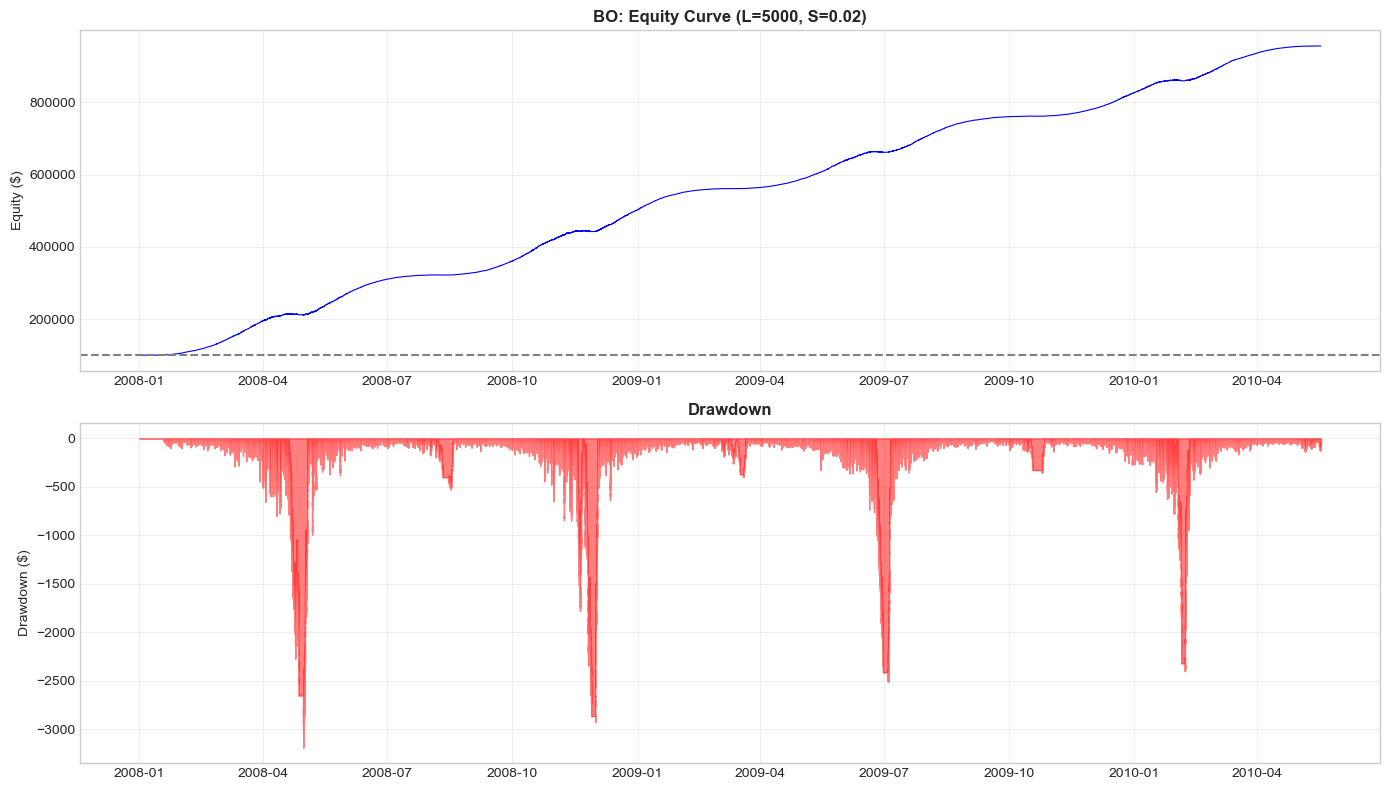

In [9]:
# Plot equity curve
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(df.index, result['Equity'], 'b-', linewidth=0.8)
axes[0].axhline(y=MARKET['E0'], color='gray', linestyle='--')
axes[0].set_title(f"{TICKER}: Equity Curve (L={test_L}, S={test_S})", fontweight='bold')
axes[0].set_ylabel('Equity ($)')
axes[0].grid(True, alpha=0.3)

axes[1].fill_between(df.index, result['Drawdown'], 0, color='red', alpha=0.5)
axes[1].set_title('Drawdown', fontweight='bold')
axes[1].set_ylabel('Drawdown ($)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'../results/04_{TICKER}_equity_test.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 3. Parameter Grid

In [10]:
# Grid configuration
QUICK_TEST = True  # Set False for full grid

if QUICK_TEST:
    L_values = np.arange(1000, 10001, 1000)  # 10 values
    S_values = np.arange(0.01, 0.06, 0.01)   # 5 values
else:
    # Full grid as specified
    L_values = np.arange(500, 10001, 10)     # 951 values
    S_values = np.arange(0.005, 0.101, 0.001) # 96 values

print(f"Grid: {len(L_values)} x {len(S_values)} = {len(L_values)*len(S_values)} combinations")

Grid: 10 x 5 = 50 combinations


---
## 4. Walk-Forward Optimization

In [11]:
def walk_forward(df, L_values, S_values, T_years=4, tau_quarters=1, slpg=24, PV=1000, E0=100000, verbose=True):
    """
    Walk-Forward Optimization.
    IS = T years, OOS = tau quarters, roll forward by tau.
    """
    total_bars = len(df)
    total_days = (df.index.max() - df.index.min()).days
    bars_per_day = total_bars / total_days if total_days > 0 else 78
    bars_per_year = int(bars_per_day * 252)
    bars_per_quarter = int(bars_per_year / 4)
    
    IS_bars = T_years * bars_per_year
    OOS_bars = tau_quarters * bars_per_quarter
    
    if verbose:
        print(f"Walk-Forward: IS={T_years}yr ({IS_bars:,} bars), OOS={tau_quarters}Q ({OOS_bars:,} bars)")
    
    results = []
    current_idx = 0
    period = 1
    
    while current_idx + IS_bars + OOS_bars <= total_bars:
        is_start = current_idx
        is_end = is_start + IS_bars
        oos_start = is_end
        oos_end = oos_start + OOS_bars
        
        if verbose:
            print(f"\nPeriod {period}: IS {df.index[is_start].strftime('%Y-%m-%d')} to {df.index[is_end-1].strftime('%Y-%m-%d')}")
        
        # IS optimization
        best_obj = -np.inf
        best_L, best_S = L_values[0], S_values[0]
        best_is = None
        
        for L in tqdm(L_values, desc=f"Period {period}", leave=False):
            for S in S_values:
                res = run_backtest(df, int(L), float(S), slpg, PV, E0, is_start, is_end)
                if not res.get('error') and res['Objective'] > best_obj:
                    best_obj = res['Objective']
                    best_L, best_S = int(L), float(S)
                    best_is = res
        
        if best_is is None:
            current_idx += OOS_bars
            period += 1
            continue
        
        # OOS evaluation
        oos = run_backtest(df, best_L, best_S, slpg, PV, E0, oos_start, oos_end)
        
        if verbose:
            print(f"  Best: L={best_L}, S={best_S:.3f}")
            print(f"  IS: Profit=${best_is['Profit']:,.0f}, Obj={best_is['Objective']:.3f}")
            print(f"  OOS: Profit=${oos['Profit']:,.0f}, Obj={oos['Objective']:.3f}")
        
        results.append({
            'Period': period,
            'L': best_L,
            'S': best_S,
            'IS_Profit': best_is['Profit'],
            'IS_Objective': best_is['Objective'],
            'OOS_Profit': oos['Profit'],
            'OOS_Objective': oos['Objective'],
            'OOS_Trades': oos['NumTrades'],
        })
        
        current_idx += OOS_bars
        period += 1
    
    return pd.DataFrame(results)

In [12]:
# Run Walk-Forward
print("Starting Walk-Forward Optimization...\n")

wf_results = walk_forward(
    df, L_values, S_values,
    T_years=4, tau_quarters=1,
    slpg=MARKET['slpg'], PV=MARKET['PV'], E0=MARKET['E0'],
    verbose=True
)

Starting Walk-Forward Optimization...

Walk-Forward: IS=4yr (290,320 bars), OOS=1Q (18,145 bars)


In [13]:
# Summary
if len(wf_results) > 0:
    print("\n" + "=" * 60)
    print(f"WALK-FORWARD SUMMARY: {TICKER}")
    print("=" * 60)
    print(f"\nPeriods: {len(wf_results)}")
    print(f"Total OOS Profit: ${wf_results['OOS_Profit'].sum():,.2f}")
    print(f"Mean IS Objective: {wf_results['IS_Objective'].mean():.3f}")
    print(f"Mean OOS Objective: {wf_results['OOS_Objective'].mean():.3f}")
    print(f"Decay: {wf_results['OOS_Objective'].mean() / wf_results['IS_Objective'].mean():.1%}")
    print(f"\n{wf_results.to_string(index=False)}")

In [14]:
# Visualize
if len(wf_results) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # IS vs OOS Profit
    x = np.arange(len(wf_results))
    axes[0,0].bar(x - 0.2, wf_results['IS_Profit']/1000, 0.4, label='IS', alpha=0.7)
    axes[0,0].bar(x + 0.2, wf_results['OOS_Profit']/1000, 0.4, label='OOS', alpha=0.7)
    axes[0,0].set_title('IS vs OOS Profit', fontweight='bold')
    axes[0,0].set_ylabel('Profit ($K)')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Objective
    axes[0,1].plot(wf_results['Period'], wf_results['IS_Objective'], 'bo-', label='IS')
    axes[0,1].plot(wf_results['Period'], wf_results['OOS_Objective'], 'go-', label='OOS')
    axes[0,1].set_title('Objective (Profit/MaxDD)', fontweight='bold')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Parameters
    axes[1,0].plot(wf_results['Period'], wf_results['L'], 'ro-')
    axes[1,0].set_title('Optimal L by Period', fontweight='bold')
    axes[1,0].set_ylabel('L')
    ax2 = axes[1,0].twinx()
    ax2.plot(wf_results['Period'], wf_results['S'], 'ms-')
    ax2.set_ylabel('S', color='magenta')
    axes[1,0].grid(True, alpha=0.3)
    
    # Cumulative OOS
    cum = MARKET['E0'] + wf_results['OOS_Profit'].cumsum()
    axes[1,1].plot(wf_results['Period'], cum/1000, 'g-', linewidth=2)
    axes[1,1].axhline(y=MARKET['E0']/1000, color='gray', linestyle='--')
    axes[1,1].set_title('Cumulative OOS Equity', fontweight='bold')
    axes[1,1].set_ylabel('Equity ($K)')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'../results/05_{TICKER}_walkforward.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## Next: Notebook 03 - Performance Metrics & Extended Analysis

**End of Notebook 02**